# WWWMD 3: Gaps in Player Trajectory (Starter)

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [2]:
import os
cwd = os.getcwd()

## WWWMD 3

In [3]:
df_3 = pd.read_csv(cwd + '/trajectory_data.csv')
df_3.head()

,frame,time,x_position,y_position
0,1206723,12.000000,22.577133,13.729999
1,1206722,12.040201,22.780341,12.750863
2,1206721,12.080402,23.145704,11.819998
3,1206720,12.120603,22.628282,12.675728
4,1206719,12.160804,22.411127,13.651865


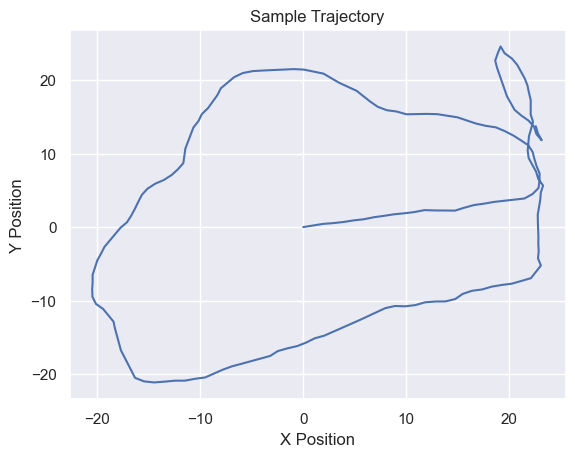

In [4]:
plt.plot(df_3['x_position'], df_3['y_position'])
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Sample Trajectory')
plt.show()

Next, plot each data point (not just a connected line) so you can see how the points are spaced along the trajectory.


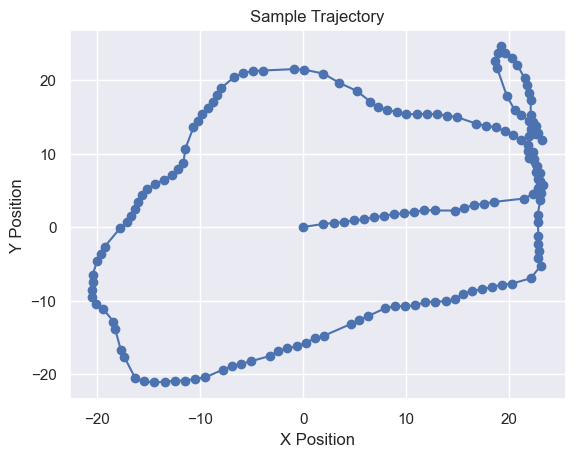

In [5]:
plt.plot(df_3['x_position'], df_3['y_position'], 'o-')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Sample Trajectory')
plt.show()

 # EXPLORING

In [16]:
# length of data
len(df_3)

160

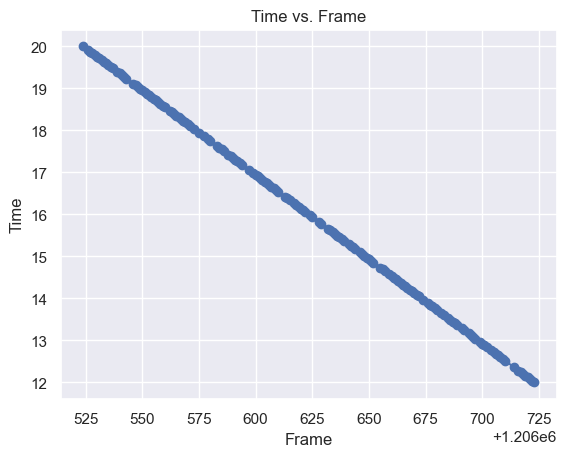

In [17]:
plt.plot(df_3['frame'], df_3['time'], 'o-')
plt.xlabel('Frame')
plt.ylabel('Time')
plt.title('Time vs. Frame')
plt.show()

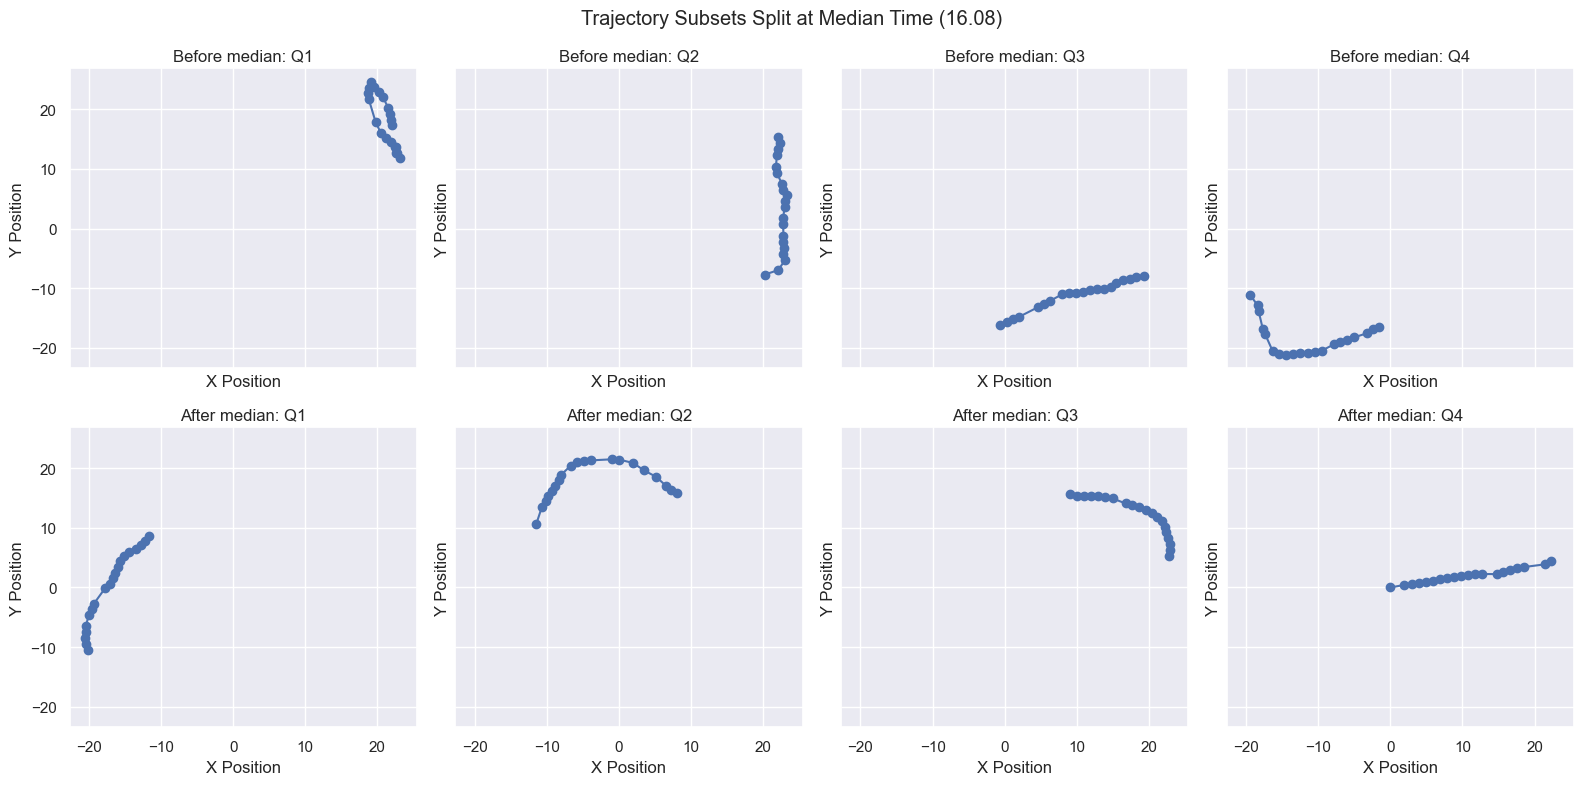

In [18]:
median_time = df_3['time'].median()

df_time = df_3.copy()
df_time['side'] = np.where(df_time['time'] <= median_time, 'Before median', 'After median')

df_time['quartile'] = (
    df_time.groupby('side', group_keys=False)['time']
    .transform(lambda x: pd.qcut(x, 4, labels=['Q1', 'Q2', 'Q3', 'Q4']))
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for row, side in enumerate(['Before median', 'After median']):
    for col, quartile in enumerate(['Q1', 'Q2', 'Q3', 'Q4']):
        subset = df_time[
            (df_time['side'] == side) &
            (df_time['quartile'] == quartile)
        ]

        axes[row, col].plot(
            subset['x_position'],
            subset['y_position'],
            'o-'
        )
        axes[row, col].set_title(f'{side}: {quartile}')
        axes[row, col].set_xlabel('X Position')
        axes[row, col].set_ylabel('Y Position')
        axes[row, col].grid(True)

plt.suptitle(f'Trajectory Subsets Split at Median Time ({median_time:.2f})')
plt.tight_layout()
plt.show()

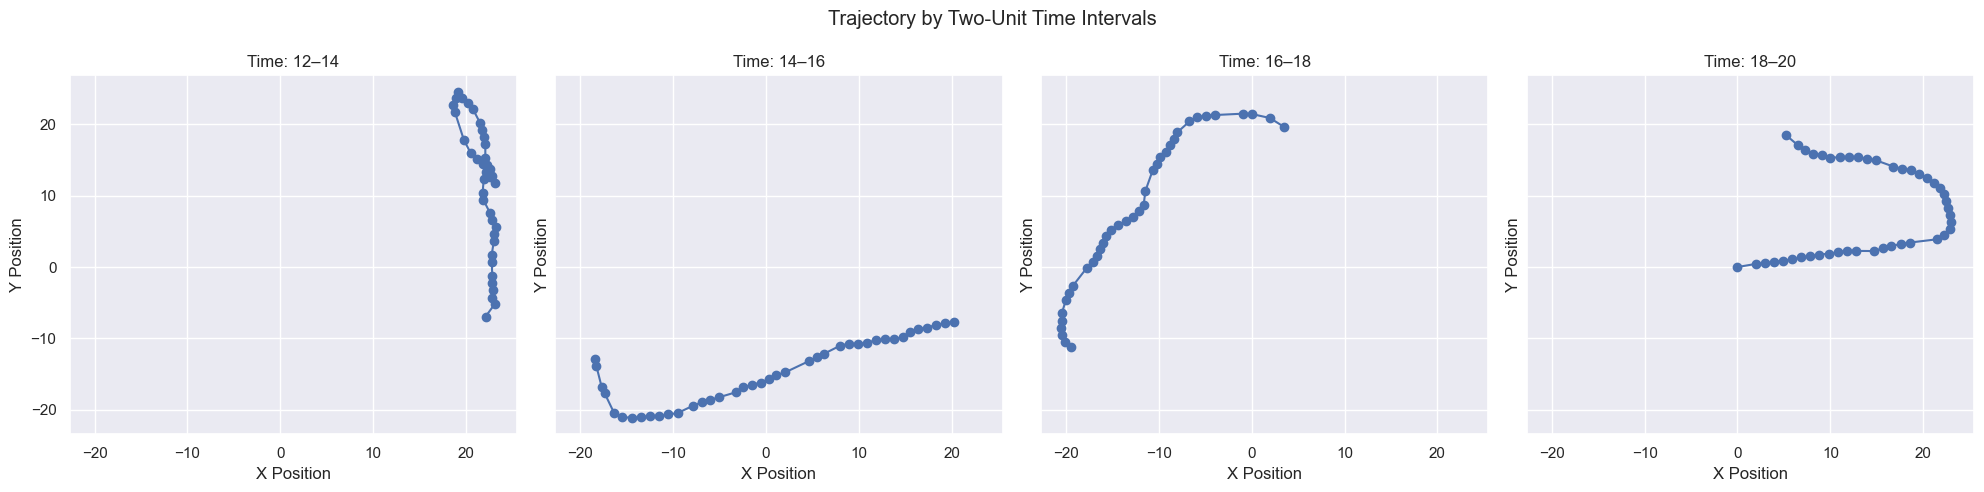

In [19]:
# Create two-unit time intervals
time_start = np.floor(df_3['time'].min() / 2) * 2
time_end = np.ceil(df_3['time'].max() / 2) * 2
bins = np.arange(time_start, time_end + 2, 2)

labels = [
    f'{start:.0f}–{end:.0f}'
    for start, end in zip(bins[:-1], bins[1:])
]

df_time_increment = df_3.copy()
df_time_increment['time_interval'] = pd.cut(
    df_time_increment['time'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fig, axes = plt.subplots(
    1, len(labels),
    figsize=(5 * len(labels), 5),
    sharex=True,
    sharey=True
)

for ax, interval in zip(np.atleast_1d(axes), labels):
    subset = df_time_increment[
        df_time_increment['time_interval'] == interval
    ]

    ax.plot(
        subset['x_position'],
        subset['y_position'],
        'o-'
    )
    ax.set_title(f'Time: {interval}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.grid(True)

plt.suptitle('Trajectory by Two-Unit Time Intervals')
plt.tight_layout()
plt.show()

Average time between frames: 0.0503


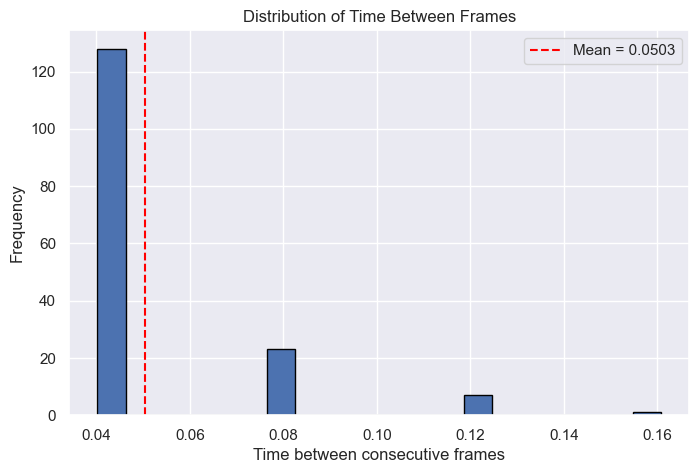

In [20]:
# Calculate time differences between consecutive frames
df_sorted = df_3.sort_values('frame')
time_between_frames = df_sorted['time'].diff().abs().dropna()

print(f'Average time between frames: {time_between_frames.mean():.4f}')

plt.figure(figsize=(8, 5))
plt.hist(time_between_frames, bins=20, edgecolor='black')
plt.xlabel('Time between consecutive frames')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Frames')
plt.axvline(
    time_between_frames.mean(),
    color='red',
    linestyle='--',
    label=f'Mean = {time_between_frames.mean():.4f}'
)
plt.legend()
plt.show()